# 🫀 Preprocessing Notebook 1 — Lifestyle Dataset (Cardio_Data.csv)
**Project:** Genetic Risk Integration with Lifestyle & Clinical Data for Cardiovascular Disease Stratification  
**Dataset:** Cardiovascular Disease Dataset (Kaggle) — 70,000 instances  
**Output:** `df_lifestyle_train.csv`, `df_lifestyle_test.csv`, `lifestyle_scaler.pkl`

---

## 📌 What this notebook does (in order)
1. Loads raw data and creates a working copy (raw file is never modified)
2. Audits and documents the data as-is
3. Renames columns to human-readable names
4. Encodes gender (string → binary)
5. Removes physiologically impossible rows (outlier row deletion)
6. Engineers BMI feature; drops redundant height/weight
7. One-hot encodes ordinal categorical features
8. Splits into train/test (80/20, stratified) — **before any fitting**
9. Applies StandardScaler — **fit on train only** =========== GPT TOLD TO REMOVE SCALE AND JUST DO IT ON NB5 , OTHERWISE SCALING WAS BEING DONE TWICE
10. Saves clean train/test CSVs and the fitted scaler

---

## ⚠️ Critical notes before you run
- **Input file path:** update `RAW_DATA_PATH` in Section 1 if your file is elsewhere
- **Do NOT re-run imputation/scaling cells in isolation** — always run top-to-bottom to avoid leakage
- Age in this dataset is already in **decimal years** — the original Kaggle documentation incorrectly stated days. No conversion is performed.
- This dataset has **no missing values** — no imputation is needed


In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost

---
## Section 1 — Imports & Configuration

All libraries are imported here. Only standard scientific Python stack is required.  
File paths are defined as constants so they're easy to change in one place.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.model_selection import train_test_split

# ── Mount Drive ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Base Directory (STRICT — DO NOT CHANGE NAME) ────────────
BASE_DIR = "/content/drive/MyDrive/CAD_DT_Final/"

# ── Data Paths ──────────────────────────────────────────────
RAW_DATA_DIR  = BASE_DIR + "Data/Raw/"
RAW_DATA_PATH = RAW_DATA_DIR + "Cardio_Data.csv"

# ── Output Paths (CORRECT STRUCTURE) ────────────────────────
OUTPUTS_DIR   = BASE_DIR + "Outputs/"

LIFESTYLE_DIR = OUTPUTS_DIR + "Lifestyle/"

TRAIN_OUT = LIFESTYLE_DIR + "df_lifestyle_train.csv"
TEST_OUT  = LIFESTYLE_DIR + "df_lifestyle_test.csv"

# ── Create ONLY Lifestyle folder ────────────────────────────
if not os.path.exists(LIFESTYLE_DIR):
    os.makedirs(LIFESTYLE_DIR)

# ── Reproducibility ─────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20

print("✅ Setup complete")
print(f"   BASE_DIR       : {BASE_DIR}")
print(f"   RAW_DATA_PATH  : {RAW_DATA_PATH}")
# print(f"   CLINICAL_DIR   : {CLINICAL_DIR}")
print(f"   Random state   : {RANDOM_STATE}")
print(f"   Test size      : {TEST_SIZE*100:.0f}%")

# ── Validation ─────────────────────────────────────────────
assert os.path.isfile(RAW_DATA_PATH), f"❌ Missing file: {RAW_DATA_PATH}"

print("\n📂 Contents of BASE_DIR:")
print(os.listdir(BASE_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete
   BASE_DIR       : /content/drive/MyDrive/CAD_DT_Final/
   RAW_DATA_PATH  : /content/drive/MyDrive/CAD_DT_Final/Data/Raw/Cardio_Data.csv
   Random state   : 42
   Test size      : 20%

📂 Contents of BASE_DIR:
['Data', 'Outputs', 'Notebooks']


---
## Section 2 — Load Data

We load the raw CSV into `df_raw` which is **never modified**.  
All transformations happen on `df`, a working copy.  
This ensures we can always compare against the original.


In [5]:
# ── Load raw file (correct path) ────────────────────────────
df_raw = pd.read_csv(RAW_DATA_PATH)  # already defined correctly in setup

# Working copy — all transformations happen here
df = df_raw.copy()

print("=" * 55)
print("RAW DATA LOADED")
print("=" * 55)
print(f"  Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\nColumn names as loaded:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

RAW DATA LOADED
  Shape         : 70,000 rows × 12 columns
  Memory usage  : 9.7 MB

Column names as loaded:
   1. age
   2. gender
   3. height
   4. weight
   5. ap_hi
   6. ap_lo
   7. cholesterol
   8. gluc
   9. smoke
  10. alco
  11. active
  12. target


---
## Section 3 — Data Audit (Inspect Before Touching Anything)

Before any transformation, we thoroughly document the data as-is.  
This serves as the baseline for your paper's data description section.

### Key things to confirm here:
- `age` is in **decimal years** (NOT days — the original paper had this wrong)
- `gender` is a string column (`'m'` / `'f'`), not numeric
- No null values exist in this dataset
- Blood pressure extremes (will be handled in Section 6)


In [6]:
print("=" * 55)
print("AUDIT: DATA TYPES")
print("=" * 55)
print(df.dtypes)

print()
print("=" * 55)
print("AUDIT: MISSING VALUES")
print("=" * 55)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  ✅ No missing values found in any column.")
else:
    print(missing[missing > 0])

print()
print("=" * 55)
print("AUDIT: DESCRIPTIVE STATISTICS (numeric columns)")
print("=" * 55)
print(df.describe().round(2))


AUDIT: DATA TYPES
age            float64
gender          object
height           int64
weight           int64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
target           int64
dtype: object

AUDIT: MISSING VALUES
  ✅ No missing values found in any column.

AUDIT: DESCRIPTIVE STATISTICS (numeric columns)
            age    height    weight     ap_hi     ap_lo  cholesterol  \
count  70000.00  70000.00  70000.00  70000.00  70000.00     70000.00   
mean      53.34    164.36     74.21    128.82     96.63         1.37   
std        6.76      8.21     14.40    154.01    188.47         0.68   
min       29.58     55.00     10.00   -150.00    -70.00         1.00   
25%       48.39    159.00     65.00    120.00     80.00         1.00   
50%       53.98    165.00     72.00    120.00     80.00         1.00   
75%       58.43    170.00     82.00    140.00     90.00         2.00   
m

In [7]:
print("=" * 55)
print("AUDIT: CATEGORICAL COLUMNS")
print("=" * 55)

print("\ngender value counts:")
print(df['gender'].value_counts())
print(f"  → Female: {(df['gender']=='f').sum():,}  ({(df['gender']=='f').mean()*100:.1f}%)")
print(f"  → Male  : {(df['gender']=='m').sum():,}  ({(df['gender']=='m').mean()*100:.1f}%)")

print("\ncholesterol value counts (1=normal, 2=above normal, 3=well above normal):")
print(df['cholesterol'].value_counts().sort_index())

print("\ngluc value counts (1=normal, 2=above normal, 3=well above normal):")
print(df['gluc'].value_counts().sort_index())

print("\nsmoke:", df['smoke'].value_counts().to_dict())
print("alco  :", df['alco'].value_counts().to_dict())
print("active:", df['active'].value_counts().to_dict())

print()
print("=" * 55)
print("AUDIT: TARGET VARIABLE (class balance)")
print("=" * 55)
tc = df['target'].value_counts()
print(f"  0 = No CVD : {tc[0]:,}  ({tc[0]/len(df)*100:.1f}%)")
print(f"  1 = CVD    : {tc[1]:,}  ({tc[1]/len(df)*100:.1f}%)")
print("  → Near-perfect balance. No resampling needed.")


AUDIT: CATEGORICAL COLUMNS

gender value counts:
gender
f    45530
m    24470
Name: count, dtype: int64
  → Female: 45,530  (65.0%)
  → Male  : 24,470  (35.0%)

cholesterol value counts (1=normal, 2=above normal, 3=well above normal):
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

gluc value counts (1=normal, 2=above normal, 3=well above normal):
gluc
1    59479
2     5190
3     5331
Name: count, dtype: int64

smoke: {0: 63831, 1: 6169}
alco  : {0: 66236, 1: 3764}
active: {1: 56261, 0: 13739}

AUDIT: TARGET VARIABLE (class balance)
  0 = No CVD : 35,021  (50.0%)
  1 = CVD    : 34,979  (50.0%)
  → Near-perfect balance. No resampling needed.


In [8]:
print("=" * 55)
print("AUDIT: AGE COLUMN — confirming unit is YEARS not DAYS")
print("=" * 55)
print(f"  dtype  : {df['age'].dtype}")
print(f"  min    : {df['age'].min():.2f}  years")
print(f"  max    : {df['age'].max():.2f}  years")
print(f"  mean   : {df['age'].mean():.2f} years")
print()
print("  ✅ Age is in decimal years (already converted).")
print("  ✅ The original Kaggle documentation stated 'days' — this was INCORRECT.")
print("  ✅ No conversion will be performed.")

print()
print("=" * 55)
print("AUDIT: BLOOD PRESSURE — checking for impossible values")
print("=" * 55)
print(f"  ap_hi (systolic)  min={df['ap_hi'].min()}  max={df['ap_hi'].max()}")
print(f"  ap_lo (diastolic) min={df['ap_lo'].min()}  max={df['ap_lo'].max()}")
impossible_hi  = (df['ap_hi'] > 250) | (df['ap_hi'] < 70)
impossible_lo  = (df['ap_lo'] > 150) | (df['ap_lo'] < 40)
inverted       = df['ap_lo'] >= df['ap_hi']
print(f"  Systolic outside [70,250]  : {impossible_hi.sum():,} rows")
print(f"  Diastolic outside [40,150] : {impossible_lo.sum():,} rows")
print(f"  Diastolic >= Systolic      : {inverted.sum():,} rows")
print("  → These will be removed in Section 6 (row deletion, not capping)")


AUDIT: AGE COLUMN — confirming unit is YEARS not DAYS
  dtype  : float64
  min    : 29.58  years
  max    : 64.97  years
  mean   : 53.34 years

  ✅ Age is in decimal years (already converted).
  ✅ The original Kaggle documentation stated 'days' — this was INCORRECT.
  ✅ No conversion will be performed.

AUDIT: BLOOD PRESSURE — checking for impossible values
  ap_hi (systolic)  min=-150  max=16020
  ap_lo (diastolic) min=-70  max=11000
  Systolic outside [70,250]  : 229 rows
  Diastolic outside [40,150] : 1,034 rows
  Diastolic >= Systolic      : 1,236 rows
  → These will be removed in Section 6 (row deletion, not capping)


---
## Section 4 — Column Renaming

**Why rename?**  
- Original names like `ap_hi`, `gluc` are cryptic abbreviations  
- Human-readable names make code self-documenting  
- Required for paper clarity and for the PGS integration step later  

### Rename mapping

| Original | New Name | Reason |
|---|---|---|
| `age` | `age` | already clear |
| `gender` | `gender` | already clear |
| `height` | `height_cm` | adds unit for clarity |
| `weight` | `weight_kg` | adds unit for clarity |
| `ap_hi` | `systolic_bp` | medical standard term |
| `ap_lo` | `diastolic_bp` | medical standard term |
| `cholesterol` | `cholesterol_level` | disambiguates from 1190 dataset |
| `gluc` | `glucose_level` | expands abbreviation |
| `smoke` | `smoking` | cleaner noun form |
| `alco` | `alcohol` | expands abbreviation |
| `active` | `physical_activity` | clearer meaning |
| `target` | `target` | stays — already standard |


In [9]:
RENAME_MAP = {
    'height'      : 'height_cm',
    'weight'      : 'weight_kg',
    'ap_hi'       : 'systolic_bp',
    'ap_lo'       : 'diastolic_bp',
    'cholesterol' : 'cholesterol_level',
    'gluc'        : 'glucose_level',
    'smoke'       : 'smoking',
    'alco'        : 'alcohol',
    'active'      : 'physical_activity',
}

df.rename(columns=RENAME_MAP, inplace=True)

print("=" * 55)
print("COLUMN RENAMING COMPLETE")
print("=" * 55)
print(f"  {'Original':<20} → {'New'}")
print("  " + "-"*38)
for old, new in RENAME_MAP.items():
    print(f"  {old:<20} → {new}")
print()
print("Current columns:")
print(df.columns.tolist())


COLUMN RENAMING COMPLETE
  Original             → New
  --------------------------------------
  height               → height_cm
  weight               → weight_kg
  ap_hi                → systolic_bp
  ap_lo                → diastolic_bp
  cholesterol          → cholesterol_level
  gluc                 → glucose_level
  smoke                → smoking
  alco                 → alcohol
  active               → physical_activity

Current columns:
['age', 'gender', 'height_cm', 'weight_kg', 'systolic_bp', 'diastolic_bp', 'cholesterol_level', 'glucose_level', 'smoking', 'alcohol', 'physical_activity', 'target']


---
## Section 5 — Gender Encoding

**Why:** `gender` is currently a string column (`'m'` / `'f'`).  
All ML models require numeric input.  
Since this is a binary variable, we use simple label encoding (not one-hot).  

**Encoding:** `'f'` → `0`,  `'m'` → `1`  
(Consistent with the 1190 clinical dataset where `sex`: 0=female, 1=male)


In [10]:
# Encode before: 'm' → 1, 'f' → 0
gender_before = df['gender'].value_counts().to_dict()

df['gender'] = df['gender'].map({'f': 0, 'm': 1})

print("=" * 55)
print("GENDER ENCODING")
print("=" * 55)
print(f"  Before: {gender_before}")
print(f"  After : {df['gender'].value_counts().to_dict()}")
print(f"  dtype now: {df['gender'].dtype}")
print()
print("  Mapping applied: 'f' → 0  |  'm' → 1")
print("  ✅ Consistent with clinical dataset (sex: 0=female, 1=male)")

# Confirm no nulls introduced
assert df['gender'].isnull().sum() == 0, "Gender encoding introduced nulls!"
print("  ✅ No null values introduced")


GENDER ENCODING
  Before: {'f': 45530, 'm': 24470}
  After : {0: 45530, 1: 24470}
  dtype now: int64

  Mapping applied: 'f' → 0  |  'm' → 1
  ✅ Consistent with clinical dataset (sex: 0=female, 1=male)
  ✅ No null values introduced


---
## Section 6 — Remove Physiologically Impossible Rows

**Why row deletion instead of capping?**  
Values like `systolic_bp = 16020 mmHg` are not extreme outliers — they are data entry errors.  
Capping them would preserve fabricated data in the dataset.  
Removing them is the medically correct approach.

### Removal rules and justification

| Rule | Threshold | Justification |
|---|---|---|
| Systolic BP too high | > 250 mmHg | Highest recorded human BP ~300; >250 is implausible in population study |
| Systolic BP too low | < 70 mmHg | Below this = severe shock, incompatible with outpatient data collection |
| Diastolic BP too high | > 150 mmHg | Physiologically extreme upper bound |
| Diastolic BP too low | < 40 mmHg | Below this is incompatible with consciousness |
| Inverted BP | diastolic ≥ systolic | Physically impossible; data entry error |
| Height too low | < 100 cm | Adult population dataset; <100cm is entry error |
| Height too high | > 220 cm | Beyond plausible adult height range |
| Weight too low | < 30 kg | Incompatible with adult population |
| Weight too high | > 200 kg | Extreme outlier, likely entry error |

**Expected outcome:** ~68,600 rows retained (~98% of original)


In [11]:
n_before = len(df)

# Define each filter condition separately for clear logging
mask_sys_hi    = df['systolic_bp'] > 250
mask_sys_lo    = df['systolic_bp'] < 70
mask_dia_hi    = df['diastolic_bp'] > 150
mask_dia_lo    = df['diastolic_bp'] < 40
mask_inverted  = df['diastolic_bp'] >= df['systolic_bp']
mask_height_lo = df['height_cm'] < 100
mask_height_hi = df['height_cm'] > 220
mask_weight_lo = df['weight_kg'] < 30
mask_weight_hi = df['weight_kg'] > 200

print("=" * 55)
print("ROWS FLAGGED FOR REMOVAL (may overlap)")
print("=" * 55)
print(f"  systolic_bp > 250        : {mask_sys_hi.sum():>5,} rows")
print(f"  systolic_bp < 70         : {mask_sys_lo.sum():>5,} rows")
print(f"  diastolic_bp > 150       : {mask_dia_hi.sum():>5,} rows")
print(f"  diastolic_bp < 40        : {mask_dia_lo.sum():>5,} rows")
print(f"  diastolic >= systolic    : {mask_inverted.sum():>5,} rows")
print(f"  height_cm < 100          : {mask_height_lo.sum():>5,} rows")
print(f"  height_cm > 220          : {mask_height_hi.sum():>5,} rows")
print(f"  weight_kg < 30           : {mask_weight_lo.sum():>5,} rows")
print(f"  weight_kg > 200          : {mask_weight_hi.sum():>5,} rows")

# Combined mask: keep rows where NONE of the bad conditions are true
bad_mask = (mask_sys_hi | mask_sys_lo | mask_dia_hi | mask_dia_lo |
            mask_inverted | mask_height_lo | mask_height_hi |
            mask_weight_lo | mask_weight_hi)

df = df[~bad_mask].reset_index(drop=True)
n_after   = len(df)
n_removed = n_before - n_after

print()
print("=" * 55)
print("OUTLIER ROW REMOVAL SUMMARY")
print("=" * 55)
print(f"  Rows before  : {n_before:,}")
print(f"  Rows removed : {n_removed:,}  ({n_removed/n_before*100:.2f}%)")
print(f"  Rows after   : {n_after:,}")
print()
tc = df['target'].value_counts()
print(f"  Class balance after removal:")
print(f"    0 = No CVD : {tc[0]:,}  ({tc[0]/n_after*100:.1f}%)")
print(f"    1 = CVD    : {tc[1]:,}  ({tc[1]/n_after*100:.1f}%)")
print("  ✅ Class balance preserved after removal")


ROWS FLAGGED FOR REMOVAL (may overlap)
  systolic_bp > 250        :    40 rows
  systolic_bp < 70         :   189 rows
  diastolic_bp > 150       :   975 rows
  diastolic_bp < 40        :    59 rows
  diastolic >= systolic    : 1,236 rows
  height_cm < 100          :    29 rows
  height_cm > 220          :     1 rows
  weight_kg < 30           :     7 rows
  weight_kg > 200          :     0 rows

OUTLIER ROW REMOVAL SUMMARY
  Rows before  : 70,000
  Rows removed : 1,367  (1.95%)
  Rows after   : 68,633

  Class balance after removal:
    0 = No CVD : 34,679  (50.5%)
    1 = CVD    : 33,954  (49.5%)
  ✅ Class balance preserved after removal


---
## Section 7 — Feature Engineering: BMI

**Why BMI?**  
- BMI (Body Mass Index) is a clinically standard metric that integrates height and weight  
- It is far more informative for cardiovascular risk than height or weight individually  
- After computing BMI, raw height and weight are **redundant** and are dropped  
- This reduces dimensionality while adding a clinically meaningful feature  

**Formula:** `BMI = weight_kg / (height_m)²`

**Clinical categories (WHO standard):**

| BMI Range | Category |
|---|---|
| < 18.5 | Underweight |
| 18.5 – 24.9 | Normal |
| 25.0 – 29.9 | Overweight |
| ≥ 30.0 | Obese |

> Note: The BMI category column is kept for interpretability and EDA but **not** fed into the model (the continuous BMI value is used for scaling and modelling).


In [12]:
# Step 1: Convert height to metres
df['height_m'] = df['height_cm'] / 100

# Step 2: Compute BMI
df['bmi'] = df['weight_kg'] / (df['height_m'] ** 2)

# Step 3: Categorical BMI label (for EDA/interpretability only)
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25.0:
        return 'Normal'
    elif bmi < 30.0:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)

# Step 4: Drop raw height/weight/height_m (replaced by BMI)
df.drop(columns=['height_cm', 'weight_kg', 'height_m'], inplace=True)

print("=" * 55)
print("BMI FEATURE ENGINEERING")
print("=" * 55)
print(f"  BMI stats:")
print(f"    min  : {df['bmi'].min():.1f}")
print(f"    max  : {df['bmi'].max():.1f}")
print(f"    mean : {df['bmi'].mean():.1f}")
print(f"    std  : {df['bmi'].std():.1f}")
print()
print("  BMI category distribution:")
bmi_counts = df['bmi_category'].value_counts()
for cat, n in bmi_counts.items():
    print(f"    {cat:<14}: {n:,}  ({n/len(df)*100:.1f}%)")
print()
print("  Columns dropped: height_cm, weight_kg")
print("  Columns added  : bmi, bmi_category")
print()
print("Current columns after BMI engineering:")
print(df.columns.tolist())


BMI FEATURE ENGINEERING
  BMI stats:
    min  : 10.7
    max  : 152.6
    mean : 27.5
    std  : 5.4

  BMI category distribution:
    Normal        : 25,422  (37.0%)
    Overweight    : 24,621  (35.9%)
    Obese         : 17,953  (26.2%)
    Underweight   : 637  (0.9%)

  Columns dropped: height_cm, weight_kg
  Columns added  : bmi, bmi_category

Current columns after BMI engineering:
['age', 'gender', 'systolic_bp', 'diastolic_bp', 'cholesterol_level', 'glucose_level', 'smoking', 'alcohol', 'physical_activity', 'target', 'bmi', 'bmi_category']


---
## Section 8 — One-Hot Encoding of Ordinal Categorical Features

**Columns encoded:** `cholesterol_level`, `glucose_level`  

**Why one-hot and not ordinal/label encoding?**  
Both columns have values 1, 2, 3 which appear numeric, but they represent categories with **unequal intervals** — the difference between "normal" and "above normal" is not necessarily the same as "above normal" to "well above normal". One-hot encoding prevents the model from assuming a linear numeric relationship.  

One-hot encoding is **safe for all model types** (logistic regression, tree-based, neural networks).

**Note:** Binary columns (`smoking`, `alcohol`, `physical_activity`, `gender`) are **not** one-hot encoded — they are already 0/1 and have no ordering ambiguity.

> `bmi_category` is also NOT encoded — it is a human-readable label for EDA only and will be dropped before modelling.


---
## Section 9 — Drop bmi_category & Train/Test Split

**`bmi_category` is dropped here explicitly** — it is a string label used only for EDA.
It must be removed before the split to prevent any string dtype from entering the model.

**OHE is performed AFTER the split** — fit `pd.get_dummies` on train only, then reindex test.
This eliminates any risk of leakage from the encoding step.


In [13]:
# ── Step 1: Drop bmi_category BEFORE split ───────────────────────────────
assert 'bmi_category' in df.columns, "bmi_category column not found!"
df_model = df.drop(columns=['bmi_category'])

# Confirm no object/string columns remain (except target which is int)
obj_cols = [c for c in df_model.columns if df_model[c].dtype == object]
assert len(obj_cols) == 0, f"String columns still present: {obj_cols}"
print("✅ bmi_category dropped. No string columns remain.")
print(f"   Remaining columns: {df_model.columns.tolist()}")

# ── Step 2: Split BEFORE encoding ─────────────────────────────────────────
X = df_model.drop(columns=['target'])
y = df_model['target']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)

print(f"\n✅ Train/Test split:")
print(f"   X_train_raw : {X_train_raw.shape}")
print(f"   X_test_raw  : {X_test_raw.shape}")
print(f"   Train class balance: {y_train.value_counts().to_dict()}")
print(f"   Test class balance : {y_test.value_counts().to_dict()}")

# ── Step 3: OHE AFTER split — fit on train, apply to test ─────────────────
OHE_COLS = ['cholesterol_level', 'glucose_level']

# Fit dummies on train only
X_train_enc = pd.get_dummies(X_train_raw, columns=OHE_COLS, drop_first=False)

# Apply same encoding to test using reindex (fills missing dummies with 0)
X_test_enc = pd.get_dummies(X_test_raw, columns=OHE_COLS, drop_first=False)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Convert bool columns to int
for col in X_train_enc.columns:
    if X_train_enc[col].dtype == bool:
        X_train_enc[col] = X_train_enc[col].astype(int)
        X_test_enc[col]  = X_test_enc[col].astype(int)

X_train = X_train_enc.copy()
X_test  = X_test_enc.copy()

assert list(X_train.columns) == list(X_test.columns), "❌ Column mismatch train vs test after OHE!"
print(f"\n✅ OHE complete (fit on train only, reindexed test).")
print(f"   Feature columns ({len(X_train.columns)}): {X_train.columns.tolist()}")

# Final dtype check — no object columns allowed
bad_dtypes = [(c, str(X_train[c].dtype)) for c in X_train.columns if X_train[c].dtype == object]
assert len(bad_dtypes) == 0, f"Object dtypes found: {bad_dtypes}"
print("✅ No object/string dtypes in feature matrix.")
if 'index' in X_train.columns:
    X_train = X_train.drop(columns=['index'])
    X_test  = X_test.drop(columns=['index'])

✅ bmi_category dropped. No string columns remain.
   Remaining columns: ['age', 'gender', 'systolic_bp', 'diastolic_bp', 'cholesterol_level', 'glucose_level', 'smoking', 'alcohol', 'physical_activity', 'target', 'bmi']

✅ Train/Test split:
   X_train_raw : (54906, 10)
   X_test_raw  : (13727, 10)
   Train class balance: {0: 27743, 1: 27163}
   Test class balance : {0: 6936, 1: 6791}

✅ OHE complete (fit on train only, reindexed test).
   Feature columns (14): ['age', 'gender', 'systolic_bp', 'diastolic_bp', 'smoking', 'alcohol', 'physical_activity', 'bmi', 'cholesterol_level_1', 'cholesterol_level_2', 'cholesterol_level_3', 'glucose_level_1', 'glucose_level_2', 'glucose_level_3']
✅ No object/string dtypes in feature matrix.


---
## Section 10 — StandardScaler (fit on train only) REMOVED FROM NB1 ONLY NB5

Scaler is fit **only** on `X_train`, then applied to both splits.
Only continuous columns are scaled; binary/OHE columns are left as 0/1.


In [14]:
'''SCALE_COLS = ['age', 'bmi', 'systolic_bp', 'diastolic_bp']

for col in SCALE_COLS:
    assert col in X_train.columns, f"Column {col} not found in X_train!"

scaler = StandardScaler()
scaler.fit(X_train[SCALE_COLS])

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[SCALE_COLS] = scaler.transform(X_train[SCALE_COLS])
X_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])

with open(SCALER_OUT, 'wb') as f:
    pickle.dump(scaler, f)

print("✅ StandardScaler applied (fit on train only).")
print(f"   Scaler saved: {SCALER_OUT}")
print(f"   Scaled columns: {SCALE_COLS}")
for col, mean, std in zip(SCALE_COLS, scaler.mean_, scaler.scale_):
    print(f"     {col:<18} train mean={mean:.3f}  train std={std:.3f}") '''


'SCALE_COLS = [\'age\', \'bmi\', \'systolic_bp\', \'diastolic_bp\']\n\nfor col in SCALE_COLS:\n    assert col in X_train.columns, f"Column {col} not found in X_train!"\n\nscaler = StandardScaler()\nscaler.fit(X_train[SCALE_COLS])\n\nX_train = X_train.copy()\nX_test  = X_test.copy()\n\nX_train[SCALE_COLS] = scaler.transform(X_train[SCALE_COLS])\nX_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])\n\nwith open(SCALER_OUT, \'wb\') as f:\n    pickle.dump(scaler, f)\n\nprint("✅ StandardScaler applied (fit on train only).")\nprint(f"   Scaler saved: {SCALER_OUT}")\nprint(f"   Scaled columns: {SCALE_COLS}")\nfor col, mean, std in zip(SCALE_COLS, scaler.mean_, scaler.scale_):\n    print(f"     {col:<18} train mean={mean:.3f}  train std={std:.3f}") '

---
## Section 11 — Final Validation & Save

Validation checks before saving:
- Shape check
- dtype check (no object columns)
- class balance check
- scaled columns have mean ≈ 0 on train


In [15]:
print("=" * 55)
print("FINAL VALIDATION CHECKS")
print("=" * 55)

# Shape check
print(f"  X_train shape : {X_train.shape}")
print(f"  X_test shape  : {X_test.shape}")
assert X_train.shape[1] == X_test.shape[1], "Column count mismatch!"
print(f"  ✅ Shape check passed — {X_train.shape[1]} features in both splits.")

# dtype check — no object columns
obj_train = [c for c in X_train.columns if X_train[c].dtype == object]
obj_test  = [c for c in X_test.columns  if X_test[c].dtype == object]
assert len(obj_train) == 0, f"Object dtype in X_train: {obj_train}"
assert len(obj_test)  == 0, f"Object dtype in X_test: {obj_test}"
print("  ✅ dtype check passed — no object/string columns.")
print(f"     dtypes: {X_train.dtypes.value_counts().to_dict()}")

# bmi_category must NOT be present
assert 'bmi_category' not in X_train.columns, "bmi_category leaked into X_train!"
assert 'bmi_category' not in X_test.columns,  "bmi_category leaked into X_test!"
print("  ✅ bmi_category absent from all feature matrices.")

# No NaN
assert X_train.isnull().sum().sum() == 0, "NaN in X_train!"
assert X_test.isnull().sum().sum()  == 0, "NaN in X_test!"
print("  ✅ No NaN values.")
print("  ✅ No scaling applied in NB1 — raw features preserved for model pipeline.")
'''# Scaled columns mean ≈ 0 on train
for col in SCALE_COLS:
    m = X_train[col].mean()
    assert abs(m) < 0.01, f"{col} mean not near 0: {m}"
print("  ✅ Scaled columns have mean ≈ 0 on train.")
NO SCALING IN NB1 !'''

# Class balance check
train_bal = y_train.value_counts(normalize=True)
test_bal  = y_test.value_counts(normalize=True)
print(f"  ✅ Class balance:")
print(f"     Train — 0: {train_bal.get(0,0)*100:.1f}%  1: {train_bal.get(1,0)*100:.1f}%")
print(f"     Test  — 0: {test_bal.get(0,0)*100:.1f}%   1: {test_bal.get(1,0)*100:.1f}%")

# ── Save ──────────────────────────────────────────────────────────────────────
df_train_out = X_train.copy()
df_train_out['target'] = y_train.values

df_test_out = X_test.copy()
df_test_out['target'] = y_test.values

df_train_out.to_csv(TRAIN_OUT, index=False)
df_test_out.to_csv(TEST_OUT, index=False)

print(f"\n  ✅ Saved: {TRAIN_OUT}  ({len(df_train_out):,} rows)")
print(f"  ✅ Saved: {TEST_OUT}  ({len(df_test_out):,} rows)")
#               print(f"  ✅ Saved: {SCALER_OUT}")

print(f"\n  Final feature columns ({len(X_train.columns)}):")
print(f"  {X_train.columns.tolist()}")
print()
print("=" * 55)
print("PREPROCESSING COMPLETE — LIFESTYLE DATASET")
print("=" * 55)


FINAL VALIDATION CHECKS
  X_train shape : (54906, 14)
  X_test shape  : (13727, 14)
  ✅ Shape check passed — 14 features in both splits.
  ✅ dtype check passed — no object/string columns.
     dtypes: {dtype('int64'): 12, dtype('float64'): 2}
  ✅ bmi_category absent from all feature matrices.
  ✅ No NaN values.
  ✅ No scaling applied in NB1 — raw features preserved for model pipeline.
  ✅ Class balance:
     Train — 0: 50.5%  1: 49.5%
     Test  — 0: 50.5%   1: 49.5%

  ✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Lifestyle/df_lifestyle_train.csv  (54,906 rows)
  ✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Lifestyle/df_lifestyle_test.csv  (13,727 rows)

  Final feature columns (14):
  ['age', 'gender', 'systolic_bp', 'diastolic_bp', 'smoking', 'alcohol', 'physical_activity', 'bmi', 'cholesterol_level_1', 'cholesterol_level_2', 'cholesterol_level_3', 'glucose_level_1', 'glucose_level_2', 'glucose_level_3']

PREPROCESSING COMPLETE — LIFESTYLE DATASET


In [16]:
X_train.describe()

,age,gender,systolic_bp,diastolic_bp,smoking,alcohol,physical_activity,bmi,cholesterol_level_1,cholesterol_level_2,cholesterol_level_3,glucose_level_1,glucose_level_2,glucose_level_3
count,54906.000000,54906.000000,54906.000000,54906.000000,54906.000000,54906.000000,54906.000000,54906.000000,54906.000000,54906.000000,54906.000000,54906.000000,54906.000000,54906.000000
mean,53.336863,0.348687,126.645540,81.295268,0.087531,0.053346,0.803318,27.486200,0.749190,0.135577,0.115233,0.849670,0.073744,0.076585
std,6.741979,0.476559,16.664283,9.420361,0.282615,0.224724,0.397493,5.347723,0.433484,0.342342,0.319306,0.357398,0.261357,0.265935
min,29.750685,0.000000,70.000000,40.000000,0.000000,0.000000,0.000000,10.726644,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.405479,0.000000,120.000000,80.000000,0.000000,0.000000,1.000000,23.875115,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,53.975342,0.000000,120.000000,80.000000,0.000000,0.000000,1.000000,26.346494,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,58.402740,1.000000,140.000000,90.000000,0.000000,0.000000,1.000000,30.120482,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,64.967123,1.000000,240.000000,150.000000,1.000000,1.000000,1.000000,152.551775,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


---
## Section 12 — Quick EDA Plots (Optional)


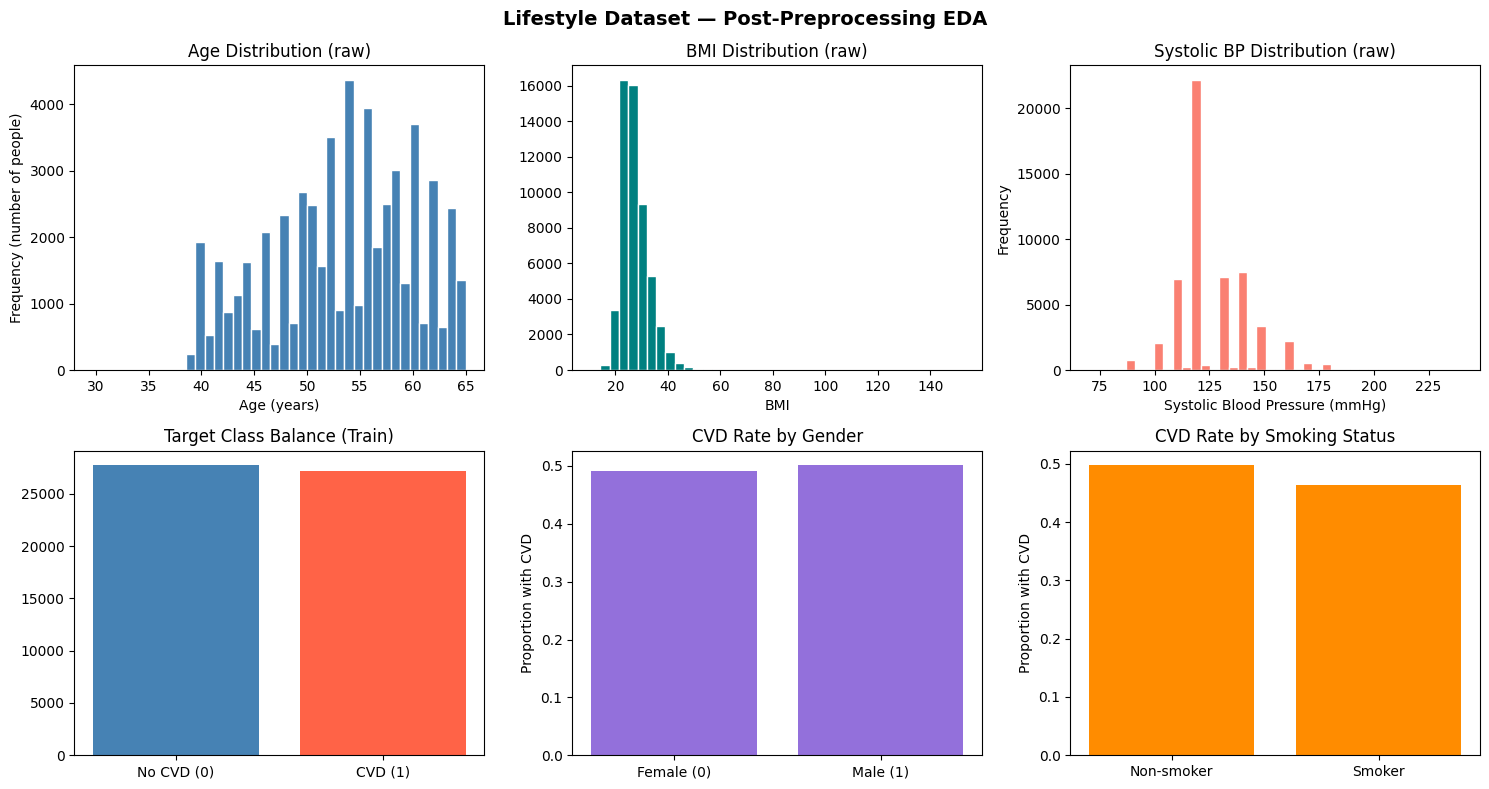


  ✅ EDA plot saved to: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/lifestyle_eda.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Lifestyle Dataset — Post-Preprocessing EDA', fontsize=14, fontweight='bold')

# 1. Age distribution
axes[0,0].hist(df_train_out['age'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution (raw)')
axes[0,0].set_xlabel('Age (years)')
axes[0,0].set_ylabel('Frequency (number of people)')
# 2. BMI distribution
axes[0,1].hist(df_train_out['bmi'], bins=40, color='teal', edgecolor='white')
axes[0,1].set_title('BMI Distribution (raw)')
axes[0,1].set_xlabel('BMI')

# 3. Systolic BP
axes[0,2].hist(df_train_out['systolic_bp'], bins=40, color='salmon', edgecolor='white')
axes[0,2].set_title('Systolic BP Distribution (raw)')
axes[0,2].set_xlabel('Systolic Blood Pressure (mmHg)')
axes[0,2].set_ylabel('Frequency')

# 4. Target balance
tc = df_train_out['target'].value_counts()
axes[1,0].bar(['No CVD (0)', 'CVD (1)'], tc.values, color=['steelblue','tomato'])
axes[1,0].set_title('Target Class Balance (Train)')

# 5. Gender vs Target
gender_target = df_train_out.groupby('gender')['target'].mean()
axes[1,1].bar(['Female (0)', 'Male (1)'], gender_target.values, color='mediumpurple')
axes[1,1].set_title('CVD Rate by Gender')
axes[1,1].set_ylabel('Proportion with CVD')

# 6. Smoking vs Target
smoke_target = df_train_out.groupby('smoking')['target'].mean()
axes[1,2].bar(['Non-smoker', 'Smoker'], smoke_target.values, color='darkorange')
axes[1,2].set_title('CVD Rate by Smoking Status')
axes[1,2].set_ylabel('Proportion with CVD')

plt.tight_layout()

eda_path = OUTPUTS_DIR + "Figures/lifestyle_eda.png"
plt.savefig(eda_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"\n  ✅ EDA plot saved to: {eda_path}")